The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


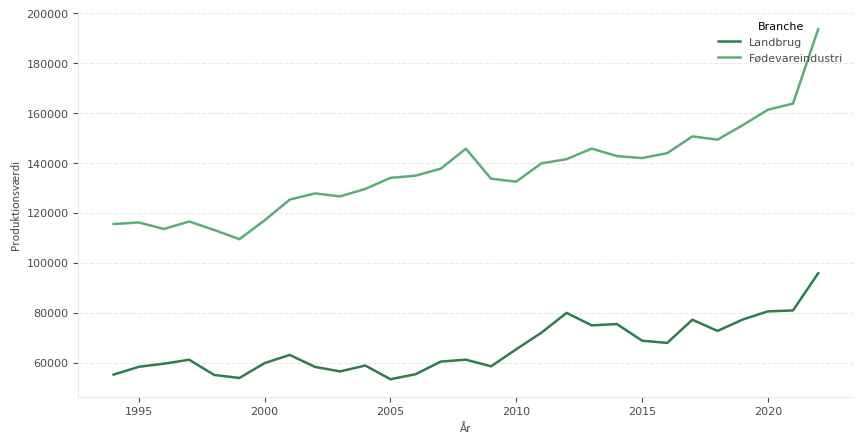

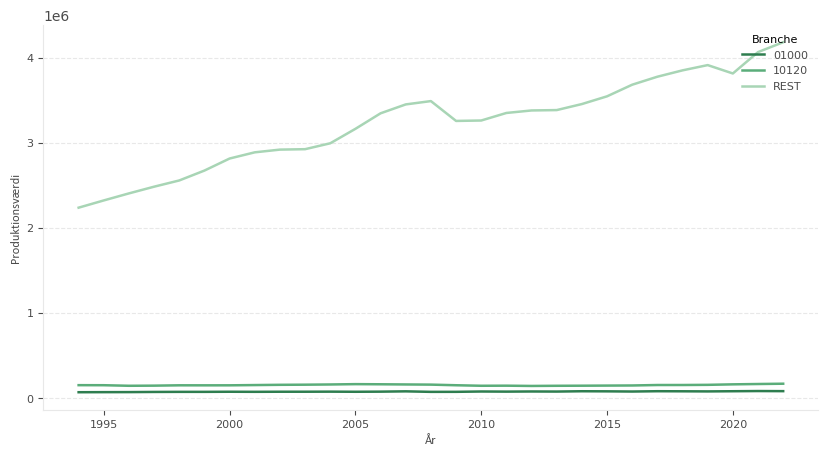

In [ ]:
%load_ext autoreload
%autoreload 2

import data_formater69 as df
import calib69 as calib
import matplotlib.pyplot as plt
import pandas as pd


# Usercost

In [23]:
df.P_I.index.names = ['ANVENDELSE', 'TID']
P_I_prev = df.P_I.groupby('ANVENDELSE')['Pt'].shift(1)
P_I_P_I_prev=df.P_I['Pt']/P_I_prev
avg = (
    P_I_P_I_prev
    .groupby('ANVENDELSE')
    .transform(lambda x: x.rolling(3).mean())  # ingen shift
)
avg.loc['01000', :]

TID
1992         NaN
1993         NaN
1994         NaN
1995         NaN
1996    1.008849
1997    1.012656
1998    1.018262
1999    1.026185
2000    1.014622
2001    1.017643
2002    1.025981
2003    1.027751
2004    1.018729
2005    1.024264
2006    1.031629
2007    1.037619
2008    1.035220
2009    1.016029
2010    1.008769
2011    0.998802
2012    1.023237
2013    1.026089
2014    1.028704
2015    1.015838
2016    1.021955
2017    1.017811
2018    1.001549
2019    1.002631
2020    1.008582
2021    1.022037
2022    1.031784
Name: Pt, dtype: float64

In [24]:

P_K=(calib.r+calib.delta)*df.P_I['Pt']-(calib.r-df.R_geld['Rt'])*0.6*df.P_I['Pt']
P_K.loc['01000', :]

P_K_dynamisk=(1+calib.r)*P_I_prev-(1-calib.delta)*df.P_I['Pt']-(calib.r-df.R_geld['Rt'])*0.6*P_I_prev
P_K_forvent=(1+calib.r)*P_I_prev-(1-calib.delta)*P_I_prev*avg-(calib.r-df.R_geld['Rt'])*0.6*P_I_prev

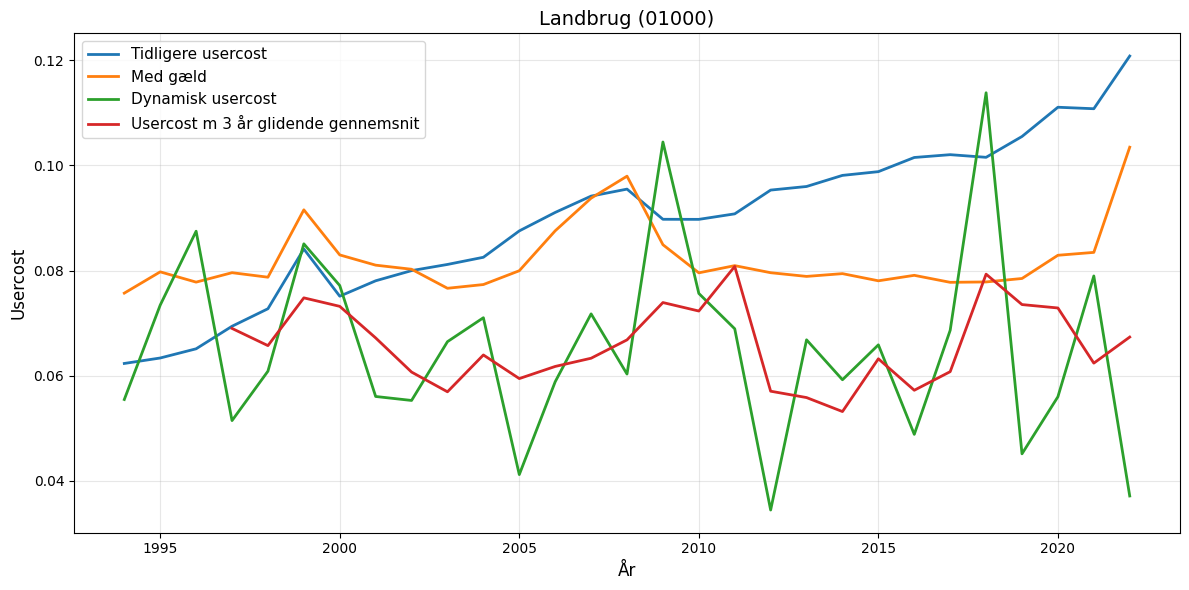

In [25]:
User_cost=calib.P_K.loc['01000', :] 
Usercost_ny=P_K.loc['01000', :] 
Usercost_prev=P_K_dynamisk.loc['01000', :]
Usercost_forvent=P_K_forvent.loc['01000', :]

User_cost_filtered = User_cost.loc[User_cost.index >= 1994]
Usercost_ny_filtered = Usercost_ny.loc[Usercost_ny.index >= 1994]
Usercost_prev_filtered = Usercost_prev.loc[Usercost_prev.index >= 1994]
Usercost_forvent_filtered = Usercost_forvent.loc[Usercost_forvent.index >= 1997]
plt.figure(figsize=(12, 6))
plt.plot(User_cost_filtered.index, User_cost_filtered.values, label='Tidligere usercost', linewidth=2)
plt.plot(Usercost_ny_filtered.index, Usercost_ny_filtered.values, label='Med gæld', linewidth=2)
plt.plot(Usercost_prev_filtered.index, Usercost_prev_filtered.values, label='Dynamisk usercost', linewidth=2)
plt.plot(Usercost_forvent_filtered.index, Usercost_forvent_filtered.values, label='Usercost m 3 år glidende gennemsnit', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Usercost', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Jordresidual

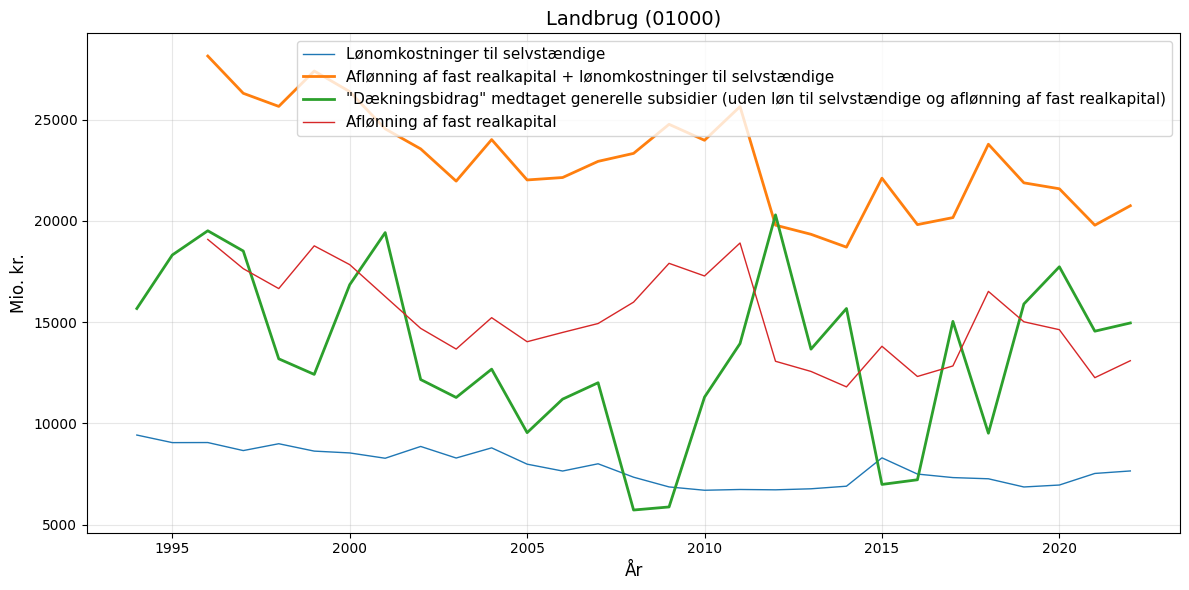

In [26]:
calib.Res.loc[ slice(1994, 2022)]
Res = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :] -calib.subs_adj.loc['01000',:]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L['Xt'].loc['01000', :]
       - P_K_forvent.loc['01000', :] * calib.K_prev.loc['01000', :])
Res.loc[slice(1994, 2022)]

DB = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L_lon['Xt'].loc['01000', :])
DB_med_subs= DB-calib.subs_adj.loc['01000',:]
L_selv=df.w['Pt'].loc['01000', :] *(df.L['Xt'].loc['01000', :] - df.L_lon['Xt'].loc['01000', :])
K_plus_L=P_K_forvent.loc['01000', :] * calib.K_prev.loc['01000', :] + L_selv
K=P_K_forvent.loc['01000', :] * calib.K_prev.loc['01000', :]
# calib.P_MxM_tot.loc['01000', :]
# calib.P_K.loc['01000', :]/2 

DB_filtered = DB.loc[DB.index >= 1994]
L_selv_filtered = L_selv.loc[L_selv.index >= 1994]
K_plus_L_filtered = K_plus_L.loc[K_plus_L.index >= 1994]
DB_med_subs_filtered = DB_med_subs.loc[DB_med_subs.index >= 1994]
K_filtered = K.loc[K.index >= 1994]

plt.figure(figsize=(12, 6))
# plt.plot(DB_filtered.index, DB_filtered.values, label='DB', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=1)
plt.plot(K_plus_L_filtered.index, K_plus_L_filtered.values, label='Aflønning af fast realkapital + lønomkostninger til selvstændige', linewidth=2)
plt.plot(DB_med_subs_filtered.index, DB_med_subs_filtered.values, label='"Dækningsbidrag" medtaget generelle subsidier (uden løn til selvstændige og aflønning af fast realkapital)', linewidth=2)
plt.plot(K_filtered.index, K_filtered.values, label='Aflønning af fast realkapital', linewidth=1)

plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

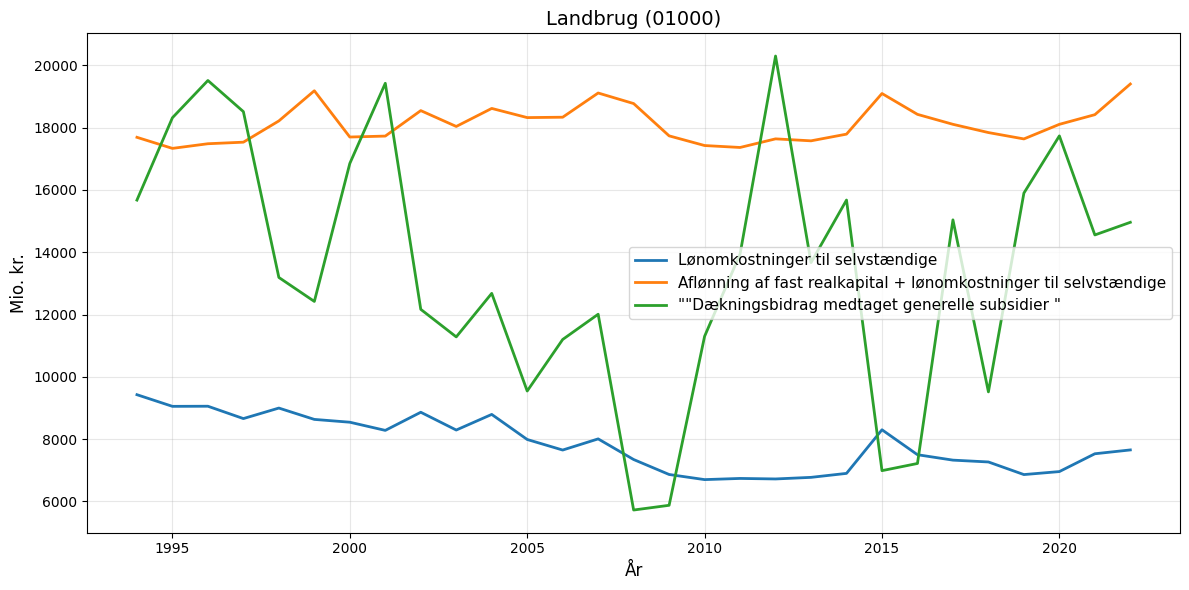

In [27]:
calib.Res.loc[ slice(1994, 2022)]
Res = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :] -calib.subs_adj.loc['01000',:]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L['Xt'].loc['01000', :]
       - calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :])
Res.loc[slice(1994, 2022)]

DB = (df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :]
       - calib.hektarstotte_adjusted
       - calib.P_MxM_tot.loc['01000', :]
       - df.w['Pt'].loc['01000', :] * df.L_lon['Xt'].loc['01000', :])
DB_med_subs= DB-calib.subs_adj.loc['01000',:]
L_selv=df.w['Pt'].loc['01000', :] *(df.L['Xt'].loc['01000', :] - df.L_lon['Xt'].loc['01000', :])
K_plus_L=calib.P_K.loc['01000', :]/2 * calib.K_prev.loc['01000', :] + L_selv
K=calib.P_K.loc['01000', :]/2 * calib.K_prev.loc['01000', :]
# calib.P_MxM_tot.loc['01000', :]
# calib.P_K.loc['01000', :]/2 

DB_filtered = DB.loc[DB.index >= 1994]
L_selv_filtered = L_selv.loc[L_selv.index >= 1994]
K_plus_L_filtered = K_plus_L.loc[K_plus_L.index >= 1994]
DB_med_subs_filtered = DB_med_subs.loc[DB_med_subs.index >= 1994]
K_filtered = K.loc[K.index >= 1994]

plt.figure(figsize=(12, 6))
# plt.plot(DB_filtered.index, DB_filtered.values, label='DB', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=2)
plt.plot(K_plus_L_filtered.index, K_plus_L_filtered.values, label='Aflønning af fast realkapital + lønomkostninger til selvstændige', linewidth=2)
plt.plot(DB_med_subs_filtered.index, DB_med_subs_filtered.values, label='""Dækningsbidrag medtaget generelle subsidier "', linewidth=2)
# plt.plot(K_filtered.index, K_filtered.values, label='K', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

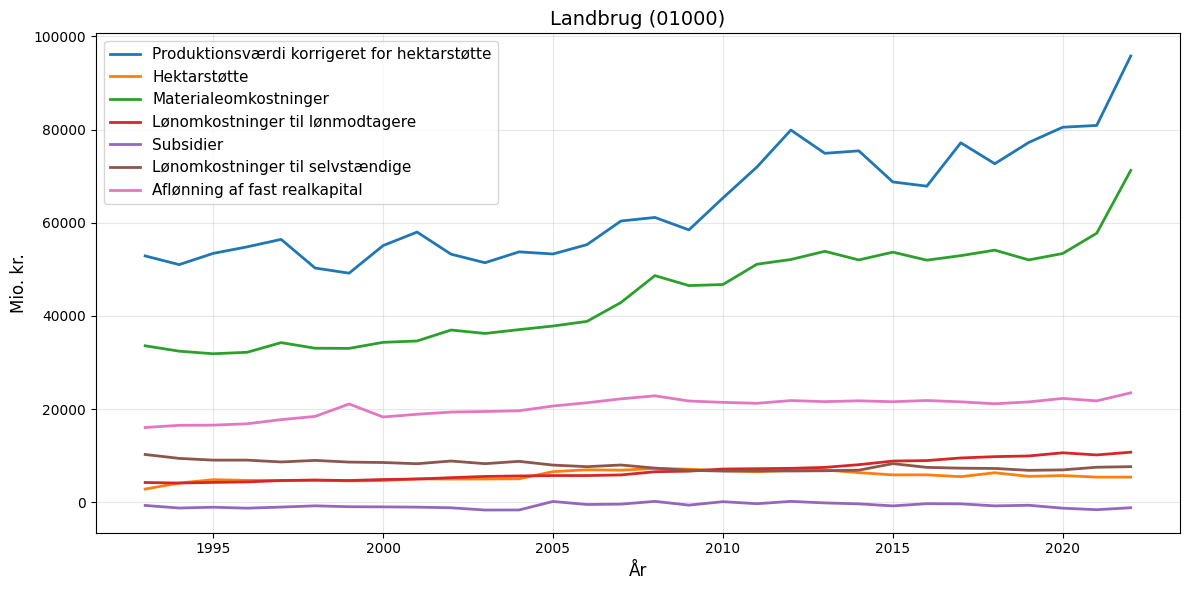

In [28]:
Produktionsværdi = df.P['Pt'].loc['01000', :] * df.Y['Xt'].loc['01000', :] - calib.hektarstotte_adjusted
Hektarstot = df.hektarstotte['INDHOLD']
Materialer =  calib.P_MxM_tot.loc['01000', :]
Lon_til_lonmodtager = df.w['Pt'].loc['01000', :] * df.L_lon['Xt'].loc['01000', :]
Subsidier= calib.subs_adj.loc['01000',:]
L_selv=df.w['Pt'].loc['01000', :] *(df.L['Xt'].loc['01000', :] - df.L_lon['Xt'].loc['01000', :])
K=calib.P_K.loc['01000', :] * calib.K_prev.loc['01000', :]

Produktionsværdi_filtered = Produktionsværdi.loc[Produktionsværdi.index >= 1993]
Hektarstot_filtered = Hektarstot.loc[Hektarstot.index >= 1993]
Materialer_filtered = Materialer.loc[Materialer.index >= 1993]
Lon_til_lonmodtager_filtered = Lon_til_lonmodtager.loc[Lon_til_lonmodtager.index >= 1993]
Subsidier_filtered = Subsidier.loc[Subsidier.index >= 1993]
L_selv_filtered = L_selv.loc[L_selv.index >= 1993]
K_filtered = K.loc[K.index >= 1993]

plt.figure(figsize=(12, 6))
plt.plot(Produktionsværdi_filtered.index, Produktionsværdi_filtered.values, label='Produktionsværdi korrigeret for hektarstøtte', linewidth=2)
plt.plot(Hektarstot_filtered.index, Hektarstot_filtered.values, label='Hektarstøtte', linewidth=2)
plt.plot(Materialer_filtered.index, Materialer_filtered.values, label='Materialeomkostninger', linewidth=2)
plt.plot(Lon_til_lonmodtager_filtered.index, Lon_til_lonmodtager_filtered.values, label='Lønomkostninger til lønmodtagere', linewidth=2)
plt.plot(Subsidier_filtered.index, Subsidier_filtered.values, label='Subsidier', linewidth=2)
plt.plot(L_selv_filtered.index, L_selv_filtered.values, label='Lønomkostninger til selvstændige', linewidth=2)
plt.plot(K_filtered.index, K_filtered.values, label='Aflønning af fast realkapital', linewidth=2)

plt.xlabel('År', fontsize=12)
plt.ylabel('Mio. kr.', fontsize=12)
plt.title('Landbrug (01000)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
with pd.ExcelWriter("modeldata_ra.xlsx") as writer:
    df.Y.unstack('TID').to_excel(writer, sheet_name="Y")
    df.Mtot.unstack('TID').to_excel(writer, sheet_name="M_tot")
    df.JKL.unstack('TID').to_excel(writer, sheet_name="JKL")
    df.KL.unstack('TID').to_excel(writer, sheet_name="KL")
    df.M_D.unstack('TID').to_excel(writer, sheet_name="M_D")
    df.M_F.unstack('TID').to_excel(writer, sheet_name="M_F")
    df.L.unstack('TID').to_excel(writer, sheet_name="L")
    df.J.unstack('TID').to_excel(writer, sheet_name="J")
    df.K.unstack('TID').to_excel(writer, sheet_name="K")
    df.MDtot.unstack('TID').to_excel(writer, sheet_name="MDtot")
    df.MFtot.unstack('TID').to_excel(writer, sheet_name="MFtot")
    
    df.P.unstack('TID').to_excel(writer, sheet_name="P")
    df.P_Mtot.unstack('TID').to_excel(writer, sheet_name="P_Mtot")
    df.P_JKL.unstack('TID').to_excel(writer, sheet_name="P_JKL")
    df.P_KL.unstack('TID').to_excel(writer, sheet_name="P_KL")
    df.P_D.unstack('TID').to_excel(writer, sheet_name="P_D")
    df.P_F.unstack('TID').to_excel(writer, sheet_name="P_F")
    df.w.unstack('TID').to_excel(writer, sheet_name="w")
    calib.P_J.to_frame().T.to_excel(writer, sheet_name="P_Jord")
    calib.P_K.unstack('TID').to_excel(writer, sheet_name="P_K")
    df.P_MDtot.unstack('TID').to_excel(writer, sheet_name="P_MDtot")
    df.P_MFtot.unstack('TID').to_excel(writer, sheet_name="P_MFtot")

In [30]:
# Laver et loop over alle variable hvor jeg tager Y og dividerer med den givne variabel
#definerer de variable det drejer sig om
variables = ['Mtot','K', 'L', 'J']
for variable in variables:
    setattr(df, f'{variable}_Y', getattr(df, variable)/df.Y )


from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Angiv PDF-filnavn
pdf_filename = "Mængder_Y.pdf"

with PdfPages(pdf_filename) as pdf:
# laver et plot over det nye variable over tid - hver branche som sin egen linje
    for variable in variables:
        theta_var = getattr(df, f'{variable}_Y')
        
        if 'ANVENDELSE' in theta_var.index.names:
            theta_wide = theta_var.unstack('ANVENDELSE').sort_index()
    
            # starter i 1993
            theta_wide = theta_wide.loc[theta_wide.index.get_level_values('TID') >= 1993]
    
            years = theta_wide.index.get_level_values('TID') if 'TID' in theta_wide.index.names else theta_wide.index
            
            plt.figure(figsize=(10, 5))
            for branche in theta_wide.columns:
                plt.plot(years, theta_wide[branche], label=branche)
    
            plt.xlabel("År")
            plt.ylabel(f"({variable}/Y)")
            plt.title(f"Mængder {variable}/Y over tid fordelt på branche")
            plt.legend(title="Branche")
            plt.grid(True, alpha=0.3)
            plt.ylim(bottom=0)
            plt.tight_layout()
            pdf.savefig()  # Gem figuren i PDF
            plt.close()


C:\Users\b431385\AppData\Local\Temp\ipykernel_25132\2176609190.py:29: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(years, theta_wide[branche], label=branche)


In [31]:
calib.P_K = calib.P_K.to_frame(name='Pt')

In [32]:
variables = ['P_Mtot', 'w', 'P_K']

for variable in variables:

    if hasattr(df, variable):
        var_data = getattr(df, variable)

    elif hasattr(calib, variable):
        var_data = getattr(calib, variable)

    setattr(df, f'{variable}_P', var_data/df.P )

# Angiv PDF-filnavn
pdf_filename = "Priser_Y.pdf"

with PdfPages(pdf_filename) as pdf:
# laver et plot over det nye variable over tid - hver branche som sin egen linje
    for variable in variables:
        theta_var = getattr(df, f'{variable}_P')

        if 'ANVENDELSE' in theta_var.index.names:
            theta_wide = theta_var.unstack('ANVENDELSE').sort_index()

            # starter i 1993
            theta_wide = theta_wide.loc[theta_wide.index.get_level_values('TID') >= 1993]

            years = theta_wide.index.get_level_values('TID') if 'TID' in theta_wide.index.names else theta_wide.index

            plt.figure(figsize=(10, 5))
            for branche in theta_wide.columns:
                plt.plot(years, theta_wide[branche], label=branche)

            plt.xlabel("År")
            plt.ylabel(f"({variable}/Y)")
            plt.title(f"Priser {variable}/Y over tid fordelt på branche")
            plt.legend(title="Branche")
            plt.grid(True, alpha=0.3)
            plt.ylim(bottom=0)
            plt.tight_layout()
            pdf.savefig()  # Gem figuren i PDF
            plt.close()

C:\Users\b431385\AppData\Local\Temp\ipykernel_25132\1109220284.py:31: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(years, theta_wide[branche], label=branche)


In [33]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Angiv PDF-filnavn
pdf_filename = "produktivitetsparametre_10120.pdf"

with PdfPages(pdf_filename) as pdf:
    # --- Figur 1 ---
    d = calib.theta_Y_KL_indeks.loc['10120', slice(1994, 2022)].copy()
    p = calib.theta_Y_Mtot_indeks.loc['10120', slice(1994, 2022)].copy()
    years = d.index.get_level_values('TID')

    plt.figure(figsize=(10,5))
    plt.plot(years, d.values, label=r'$\theta^{Y,KL}_{it}$  (Kapital + Arbejde)')
    plt.plot(years, p.values, label=r'$\theta^{Y,M}_{it}$  (Materialer)')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title("Produktivitetsparametre – Branche 10120")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    plt.tight_layout()
    pdf.savefig()  # Gem figuren i PDF
    plt.close()

    # --- Figur 2 ---
    branche = '10120'
    d = calib.theta_KL_K_indeks.loc[branche, slice(1994, 2022)]
    p = calib.theta_KL_L_indeks.loc[branche, slice(1994, 2022)]
    years = d.index.get_level_values('TID')

    plt.figure(figsize=(10,5))
    plt.plot(years, d.values, label=r'$\theta^{KL,K}_{it}$  (Kapital)')
    plt.plot(years, p.values, label=r'$\theta^{KL,L}_{it}$  (Arbejde)')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Produktivitetsparametre – Branche {branche}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 3 ---
    d = calib.theta_Mtot_M_indeks.loc[('10120', slice(None), slice(1994, 2022))].copy()
    d_wide = d.unstack('TILGANG2').sort_index()
    years = d_wide.index.get_level_values('TID')

    plt.figure(figsize=(10,5))
    for col in d_wide.columns:
        plt.plot(years, d_wide[col], label=col)
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(r'$\theta^{Mtot,M}_{it}$ Materiale-CES – Branche 10120')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 4: Landbrugssektor ---
    d = calib.theta_MD_indeks.loc[('10120','01000', slice(1994, 2022))].copy()
    p = calib.theta_MF_indeks.loc[('10120','01000', slice(1994, 2022))].copy()
    plt.figure(figsize=(10,5))
    plt.plot(years, d, label=r'$\theta^{MD}_{it}$ Danske materialer')
    plt.plot(years, p, label=r'$\theta^{MF}_{it}$ Importerede materialer')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – Landbrugssektor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 5: Fødevaresektor ---
    d = calib.theta_MD_indeks.loc[('10120','10120', slice(1994, 2022))].copy()
    p = calib.theta_MF_indeks.loc[('10120','10120', slice(1994, 2022))].copy()
    plt.figure(figsize=(10,5))
    plt.plot(years, d, label=r'$\theta^{MD}_{it}$ Danske materialer')
    plt.plot(years, p, label=r'$\theta^{MF}_{it}$ Importerede materialer')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – Fødevaresektor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 6: Resten af økonomien ---
    d = calib.theta_MD_indeks.loc[('10120','REST', slice(1994, 2022))].copy()
    p = calib.theta_MF_indeks.loc[('10120','REST', slice(1994, 2022))].copy()
    plt.figure(figsize=(10,5))
    plt.plot(years, d, label=r'$\theta^{MD}_{it}$ Danske materialer')
    plt.plot(years, p, label=r'$\theta^{MF}_{it}$ Importerede materialer')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – Resten af økonomien")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=0)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"Alle figurer er gemt i {pdf_filename}")

Alle figurer er gemt i produktivitetsparametre_10120.pdf


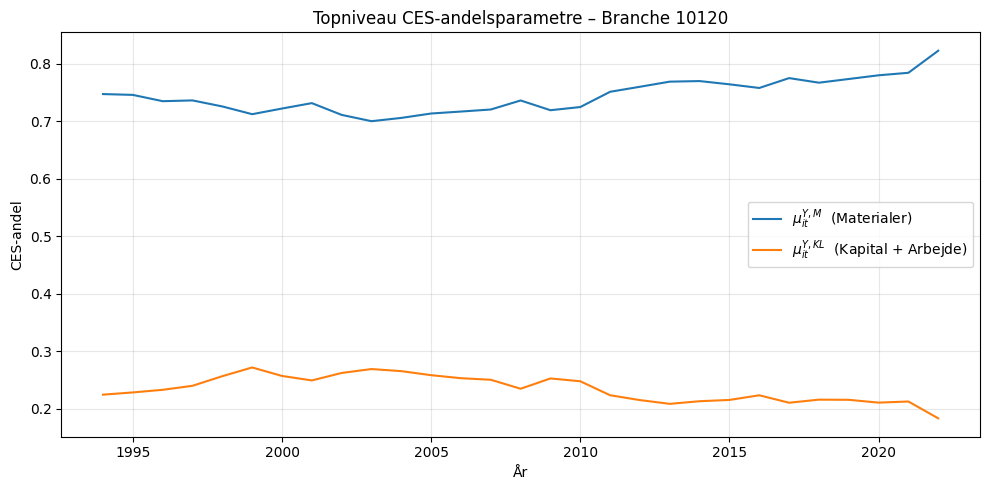

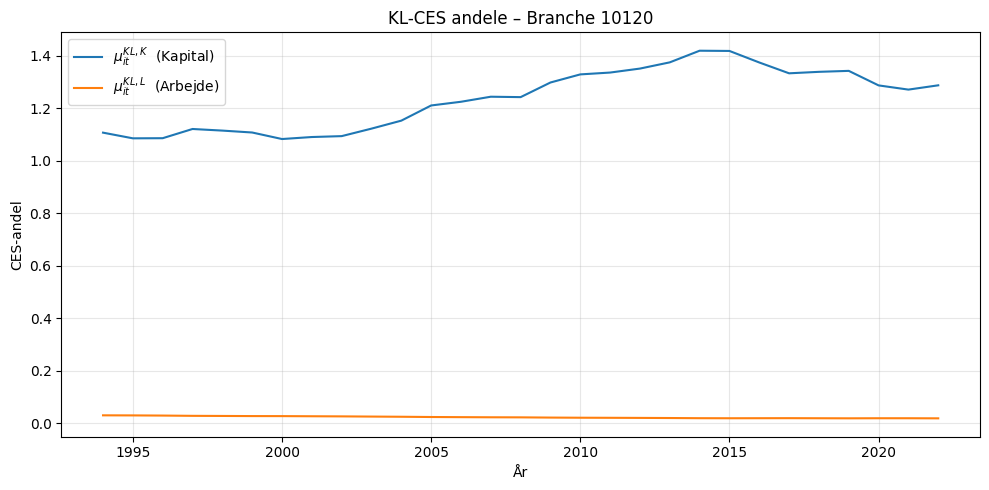

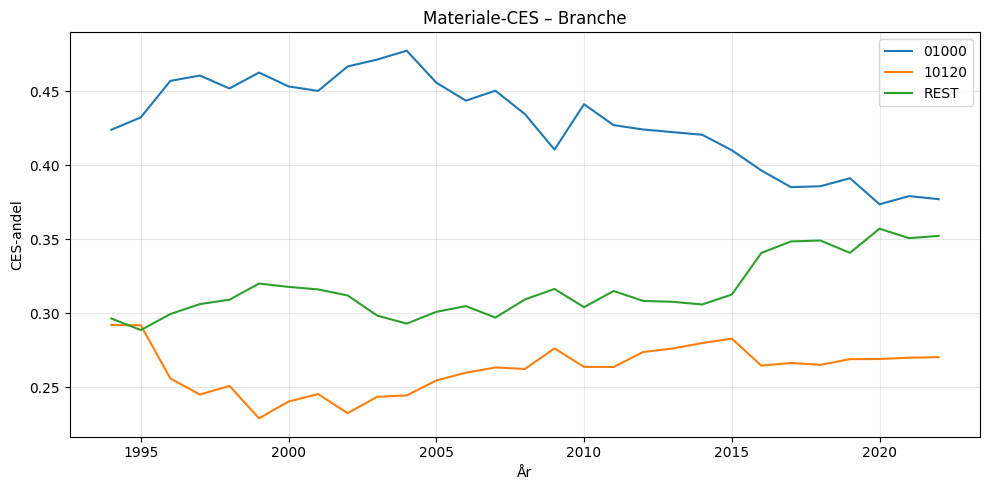

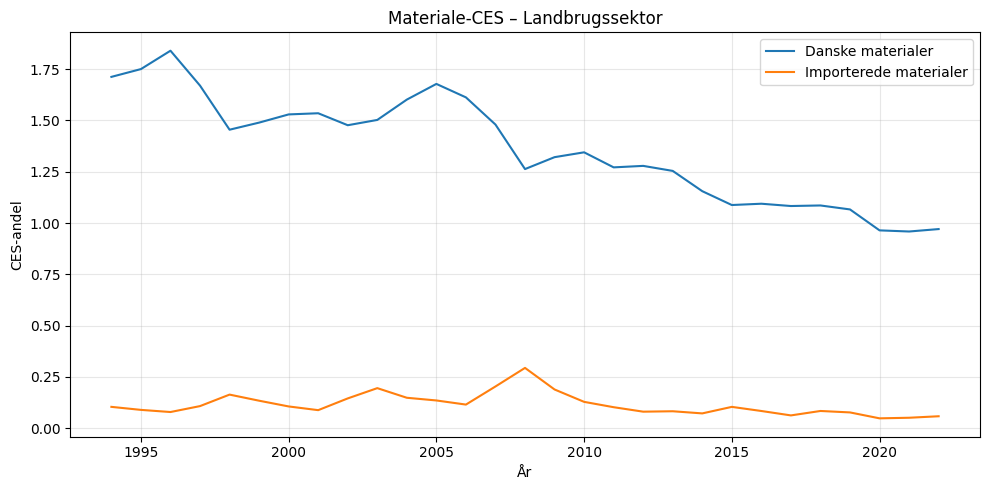

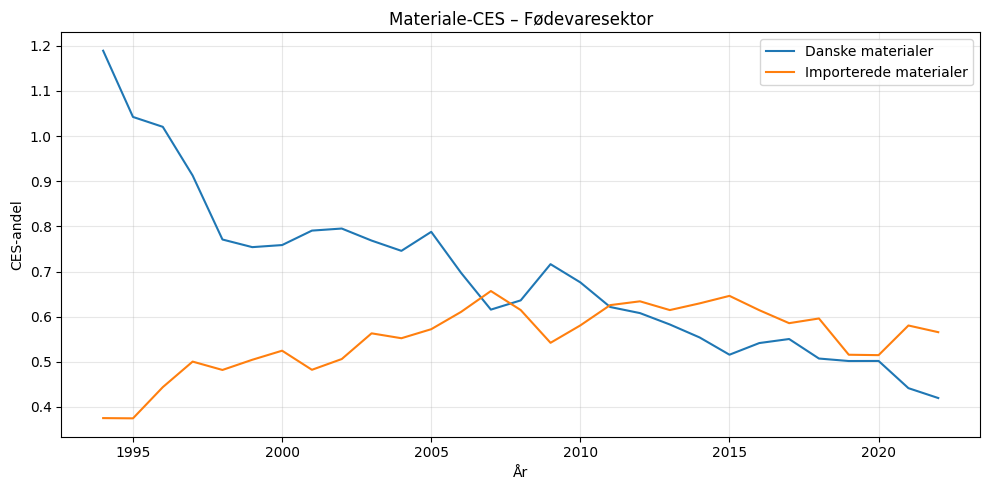

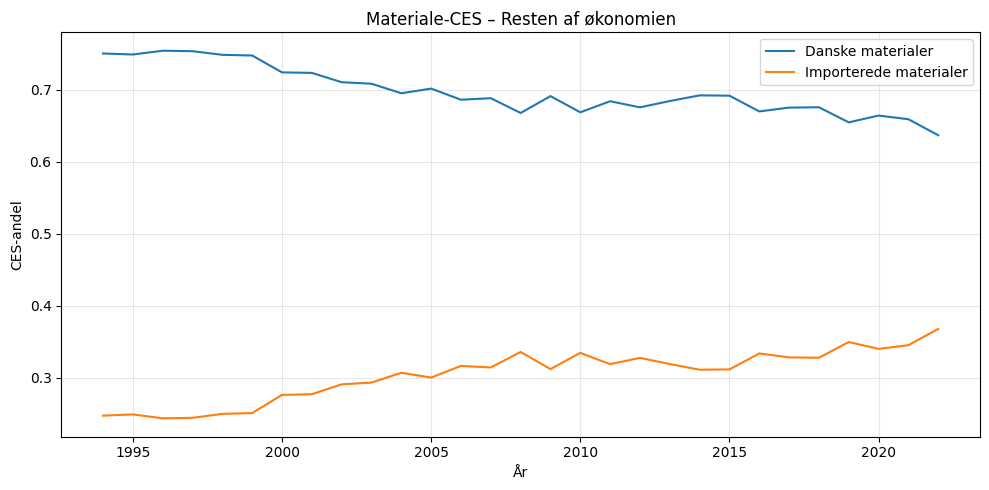

In [34]:
# Kun 1994 og frem
d = calib.mu_Y_Mtot.loc['10120', slice(1994, 2022)].copy()
p = calib.mu_Y_KL.loc['10120', slice(1994, 2022)].copy()

years = d.index.get_level_values('TID')

plt.figure(figsize=(10, 5))

plt.plot(years, d.values, label=r'$\mu^{Y,M}_{it}$  (Materialer)')
plt.plot(years, p.values, label=r'$\mu^{Y,KL}_{it}$  (Kapital + Arbejde)')

plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title("Topniveau CES-andelsparametre – Branche 10120")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

branche = '10120'   # skift hvis ønsket

d = calib.mu_KL_K.loc[branche, slice(1994, 2022)]
p = calib.mu_KL_L.loc[branche, slice(1994, 2022)]

years = d.index.get_level_values('TID')

plt.figure(figsize=(10,5))
plt.plot(years, d.values, label=r'$\mu^{KL,K}_{it}$  (Kapital)')
plt.plot(years, p.values, label=r'$\mu^{KL,L}_{it}$  (Arbejde)')

plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"KL-CES andele – Branche {branche}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_Mtot_M.loc[('10120', slice(None), slice(1994, 2022))].copy()
d_wide = d.unstack('TILGANG2').sort_index()

# Extract years (TID) from the MultiIndex for plotting
years = d_wide.index.get_level_values('TID')

plt.figure(figsize=(10,5))
for branche in d_wide.columns:
    plt.plot(years, d_wide[branche], label=branche)
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Branche")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_MD.loc[('10120','01000', slice(1994, 2022))].copy()
p = calib.mu_MF.loc[('10120', '01000', slice(1994, 2022))].copy()


plt.figure(figsize=(10,5))
plt.plot(years, d, label='Danske materialer')
plt.plot(years, p, label='Importerede materialer')
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Landbrugssektor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_MD.loc[('10120','10120', slice(1994, 2022))].copy()
p = calib.mu_MF.loc[('10120', '10120', slice(1994, 2022))].copy()


plt.figure(figsize=(10,5))
plt.plot(years, d, label='Danske materialer')
plt.plot(years, p, label='Importerede materialer')
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Fødevaresektor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_MD.loc[('10120','REST', slice(1994, 2022))].copy()
p = calib.mu_MF.loc[('10120', 'REST', slice(1994, 2022))].copy()


plt.figure(figsize=(10,5))
plt.plot(years, d, label='Danske materialer')
plt.plot(years, p, label='Importerede materialer')
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Resten af økonomien")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

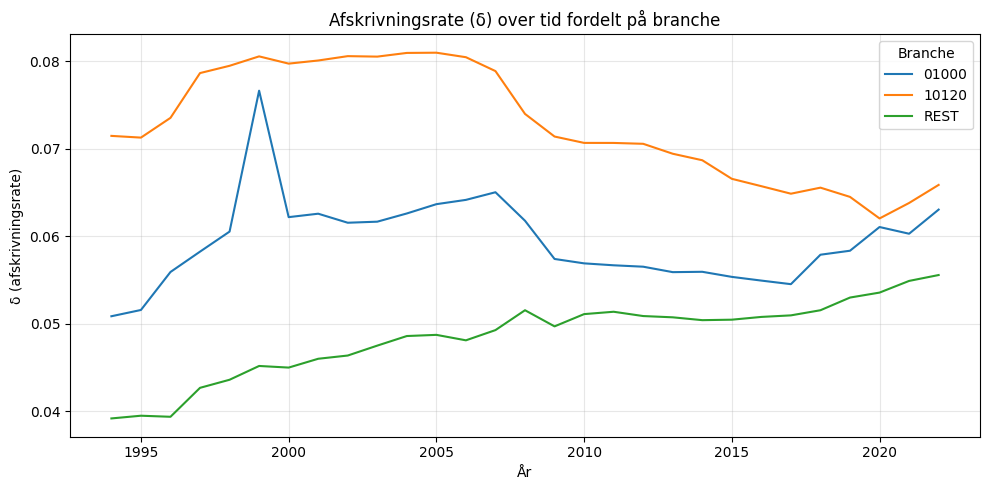

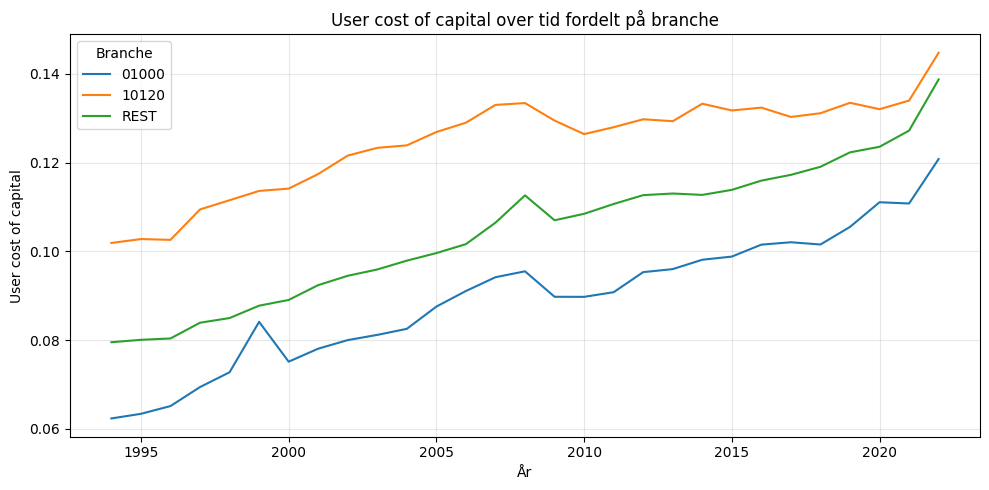

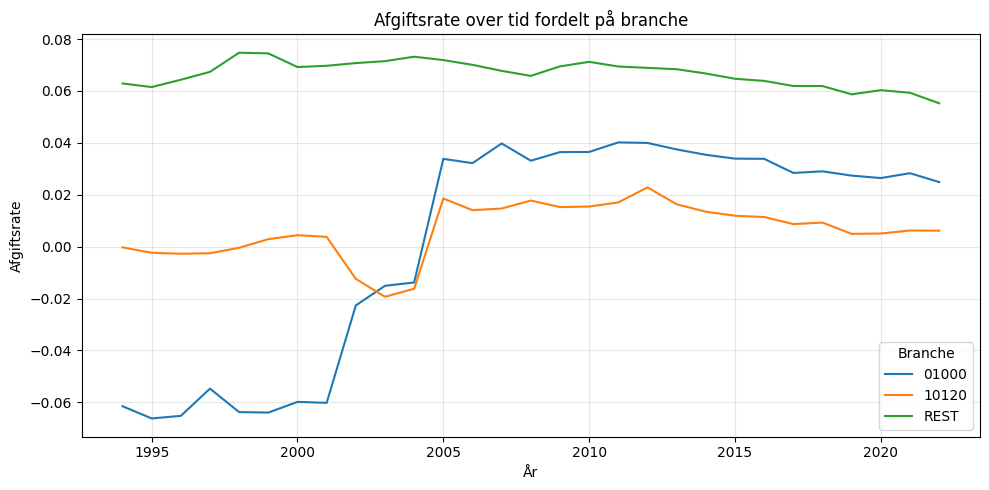

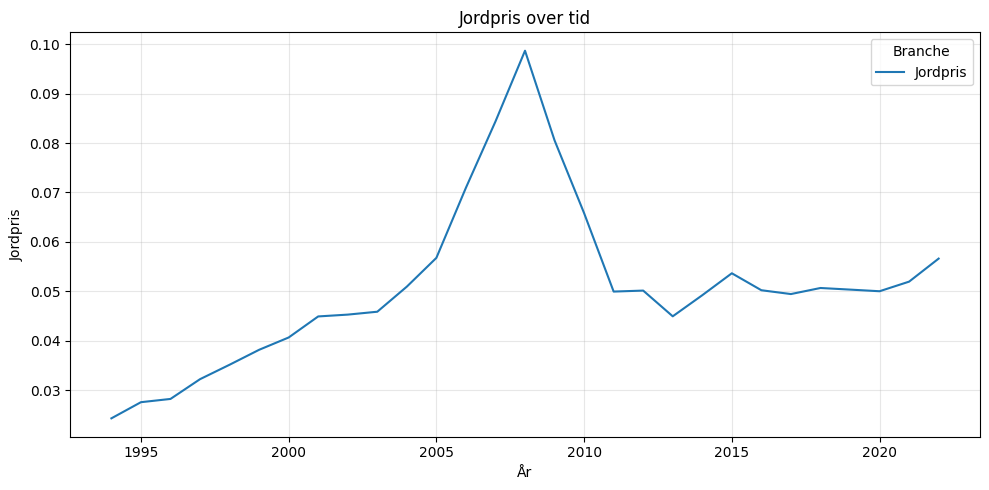

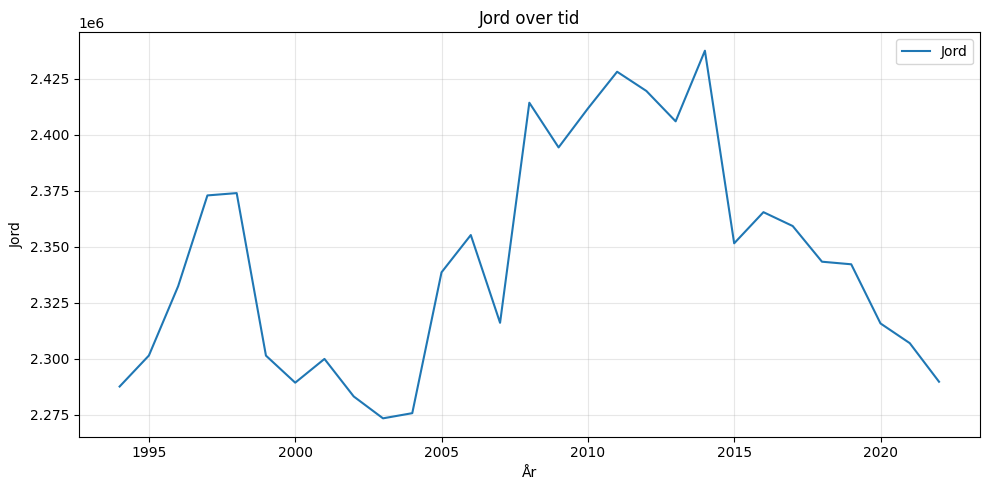

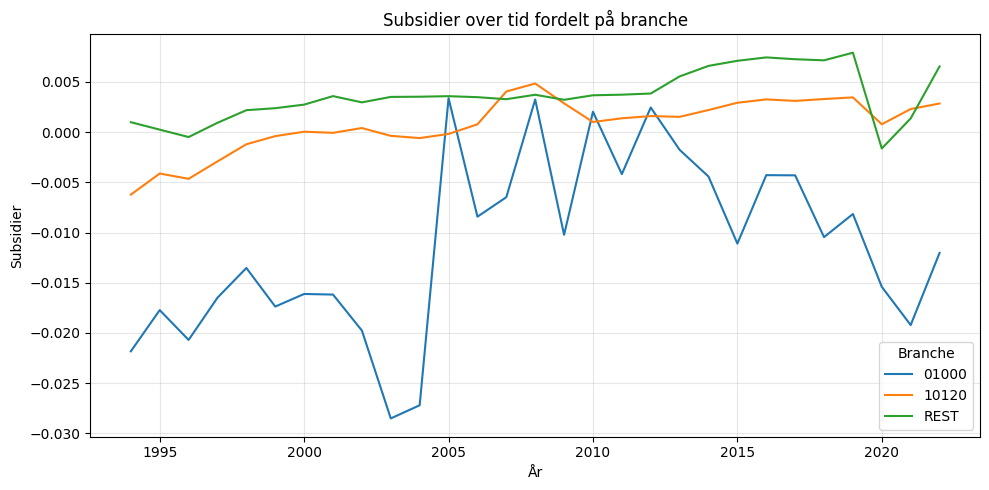

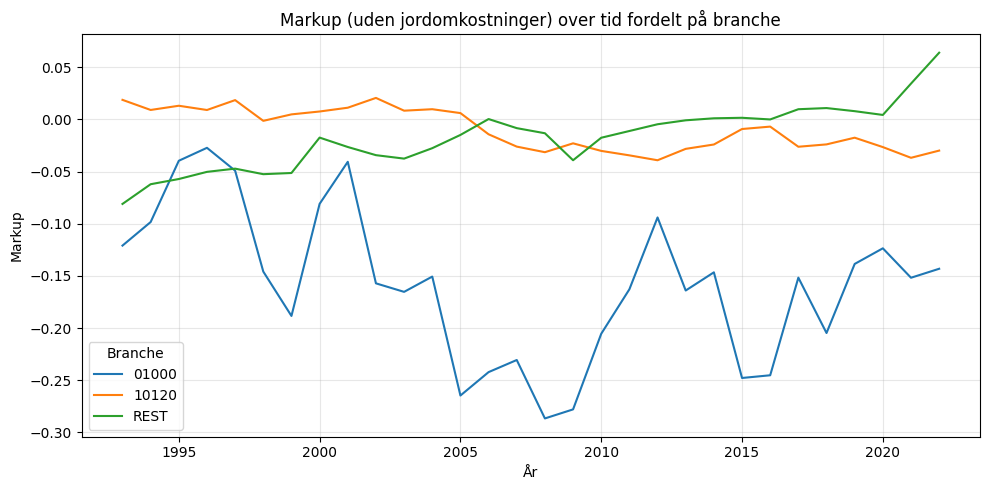

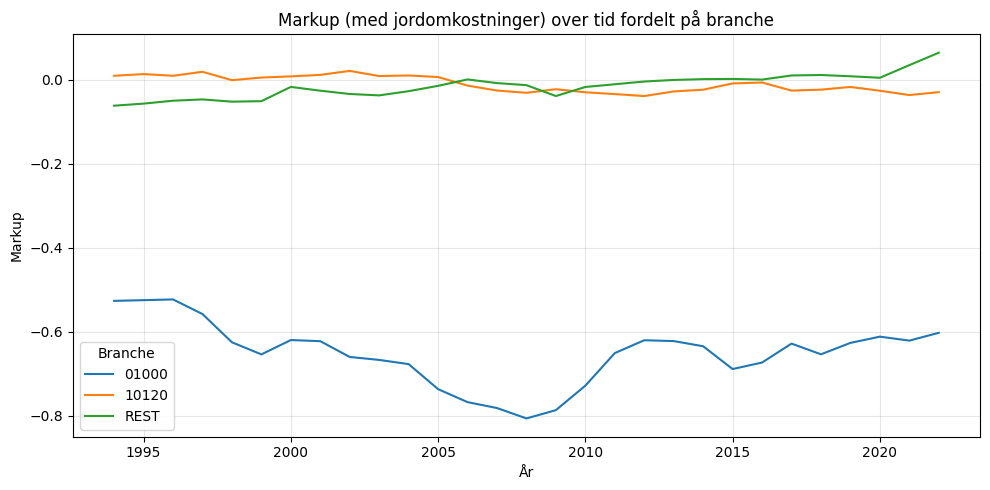

In [35]:
import matplotlib.pyplot as plt
# Kun 1993 og frem
d = calib.delta.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("δ (afskrivningsrate)")
plt.title("Afskrivningsrate (δ) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.P_K['Pt'].loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("User cost of capital")
plt.title("User cost of capital over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.tau_MD.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Afgiftsrate")
plt.title("Afgiftsrate over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.P_J.loc[(slice(1994, 2022))].copy()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(d.index, d, label='Jordpris')

plt.xlabel("År")
plt.ylabel("Jordpris")
plt.title("Jordpris over tid")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
# Få data
d = df.J['Xt'].loc['01000', slice(1994, 2022)].copy()

# Plot
plt.figure(figsize=(10, 5))
# Udtræk tidsdimensionen fra MultiIndex
years = d.index.get_level_values('TID') if 'TID' in d.index.names else d.index
plt.plot(years, d.values, label='Jord')
plt.xlabel("År")
plt.ylabel("Jord")
plt.title("Jord over tid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Kun 1993 og frem
d = calib.tau_Y.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Subsidier")
plt.title("Subsidier over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = (calib.P_MxM_tot + calib.P_KLxKL) / df.Y['Xt']
markup=df.P['Pt']/((1+calib.tau_Y)*d)-1

# Gør den "wide": år som index, branche som kolonner
d_wide = markup.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup (uden jordomkostninger) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.markup.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup (med jordomkostninger) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Datatjeks